## Read in data + filter for 2017 and 2018 only

In [5]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [6]:
spark = start_spark(num_nodes=10)

@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/charles/DATA/msk/msk_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/msk/msk_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

2026-02-03 08:47:09,951 INFO     >>> Reading enrollment file: /Users/charles/DATA/msk/msk_enrollment
2026-02-03 08:47:10,111 INFO     >>> ENROLLMENT has 756,606 rows
2026-02-03 08:47:10,442 INFO     >>> ENROLLMENT has 252,202 unique enrollees
2026-02-03 08:47:10,443 INFO     >>> Reading claims file: /Users/Charles/DATA/msk/msk_claims
2026-02-03 08:47:11,101 INFO     >>> CLAIMS has 70,785,856 rows
2026-02-03 08:47:13,854 INFO     >>> CLAIMS has 252,202 unique enrollees        


In [7]:
# First, let's prepare the annual cost data for 2017 and 2018
from pyspark.sql import functions as F

# Inflation factors
inflation_map = {
    2017: 1.0,
    2018: 1.0685946832951803,
}
infl_map = sum([[F.lit(year), F.lit(factor)] for year, factor in inflation_map.items()], [])
inflation_expr = F.create_map(*infl_map)

year1 = 2017
year2 = 2018

# Filter claims for 2017-2018 and add inflation-adjusted cost
two_year_claims = (
    df_claims
      .withColumn("YEAR", F.year("SVCDATE"))
      .filter(F.col("YEAR").between(year1, year2))
      .filter(F.col("RX").isNotNull())  # Only RX claims for cost calculation
      .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
      .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
      .drop("inflation_factor")
)

# Aggregate annual costs per enrollee per year
annual_costs = (
    two_year_claims
      .groupBy("ENROLID", "YEAR")
      .agg(F.sum("NETPAY17").alias("annual_cost17"))
)

costs_2017 = annual_costs.filter(F.col("YEAR") == 2017).select("ENROLID", "annual_cost17")
costs_2018 = annual_costs.filter(F.col("YEAR") == 2018).select("ENROLID", F.col("annual_cost17").alias("annual_cost_2018"))

logger.info(f">>> Annual costs calculated for {annual_costs.select('ENROLID').distinct().count():,} unique enrollees")

2026-02-03 08:47:16,154 INFO     >>> Annual costs calculated for 251,110 unique enrollees


# First analysis: target + msk groups + comorbidities

## Plot Cost Distribution 

In [ ]:
# Calculate cost distribution statistics and percentiles
import pandas as pd

# Convert to pandas for easier analysis (for 2018 - inflation adjusted to 2017 dollars)
costs_2018_pd = costs_2018.filter(F.col("annual_cost_2018") >= 0).toPandas()

print("="*80)
print("COST DISTRIBUTION ANALYSIS - 2018 (Inflation Adjusted to 2017 Dollars)")
print("="*80)
print(f"\nTotal enrollees: {len(costs_2018_pd):,}")
print(f"\nBasic Statistics:")
print(costs_2018_pd["annual_cost_2018"].describe())

print(f"\nPercentiles:")
percentiles = [50, 75, 90, 95, 98, 99, 99.5, 99.9]
for p in percentiles:
    val = costs_2018_pd["annual_cost_2018"].quantile(p/100)
    print(f"  {p}th percentile: ${val:,.2f}")

print(f"\nTop 2% cutoff (98th percentile): ${costs_2018_pd['annual_cost_2018'].quantile(0.98):,.2f}")
print(f"Top 1% cutoff (99th pe$lm rcentile): ${costs_2018_pd['annual_cost_2018'].quantile(0.99):,.2f}")
print(f"Top 0.5% cutoff (99.5th percentile): ${costs_2018_pd['annual_cost_2018'].quantile(0.995):,.2f}")
print(f"Top 0.1% cutoff (99.9th percentile): ${costs_2018_pd['annual_cost_2018'].quantile(0.999):,.2f}")

# Count by cost ranges
print(f"\nCost Range Distribution:")
ranges = [
    (0, 10000, "$0-$10k"),
    (10000, 25000, "$10k-$25k"),
    (25000, 50000, "$25k-$50k"),
    (50000, 100000, "$50k-$100k"),
    (100000, 200000, "$100k-$200k"),
    (200000, 500000, "$200k-$500k"),
    (500000, float('inf'), "$500k+")
]

for low, high, label in ranges:
    if high == float('inf'):
        count = len(costs_2018_pd[costs_2018_pd["annual_cost_2018"] >= low])
    else:
        count = len(costs_2018_pd[(costs_2018_pd["annual_cost_2018"] >= low) & (costs_2018_pd["annual_cost_2018"] < high)])
    pct = (count / len(costs_2018_pd)) * 100
    print(f"  {label:15s}: {count:8,} ({pct:5.2f}%)")

COST DISTRIBUTION ANALYSIS - 2018 (Inflation Adjusted to 2017 Dollars)

Total enrollees: 246,481

Basic Statistics:
count    2.464810e+05
mean     1.496690e+04
std      2.931984e+04
min      0.000000e+00
25%      1.058521e+03
50%      4.887906e+03
75%      1.749433e+04
max      1.330460e+06
Name: annual_cost_2018, dtype: float64

Percentiles:
  50th percentile: $4,887.91
  75th percentile: $17,494.33
  90th percentile: $40,368.92
  95th percentile: $59,689.59
  98th percentile: $90,121.10
  99th percentile: $121,522.61
  99.5th percentile: $163,185.78
  99.9th percentile: $318,260.26

Top 2% cutoff (98th percentile): $90,121.10
Top 1% cutoff (99th percentile): $121,522.61
Top 0.5% cutoff (99.5th percentile): $163,185.78
Top 0.1% cutoff (99.9th percentile): $318,260.26

Cost Range Distribution:
  $0-$10k        :  159,377 (64.66%)
  $10k-$25k      :   40,552 (16.45%)
  $25k-$50k      :   29,485 (11.96%)
  $50k-$100k     :   13,218 ( 5.36%)
  $100k-$200k    :    3,080 ( 1.25%)
  $200k-$5

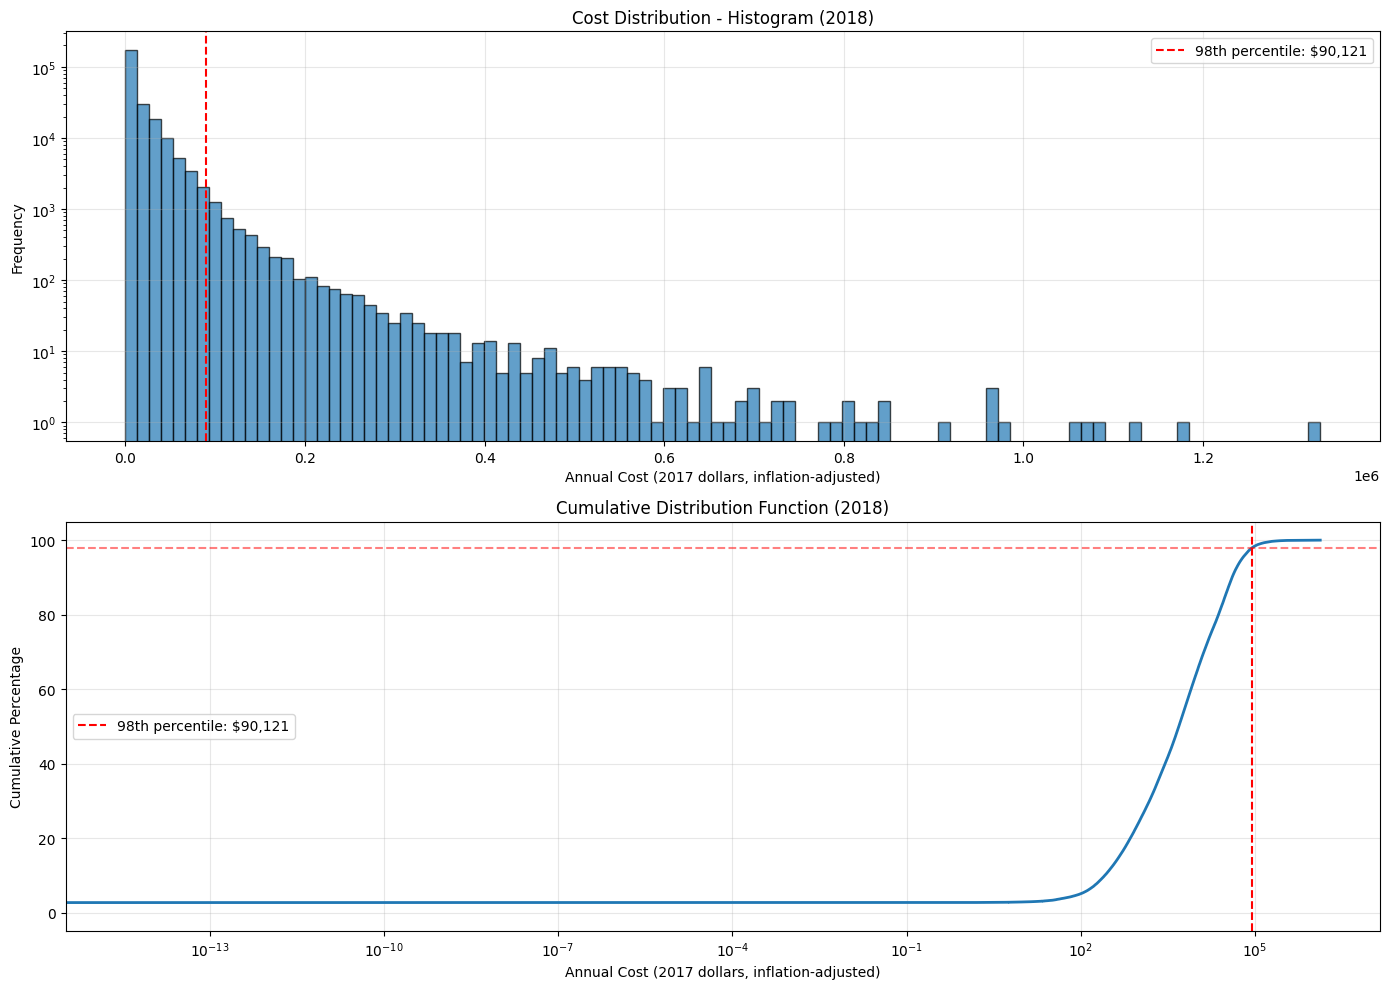

In [12]:
# Visualize cost distribution (2018 - inflation adjusted to 2017 dollars)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Histogram (log scale)
ax1 = axes[0]
ax1.hist(costs_2018_pd["annual_cost_2018"], bins=100, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Annual Cost (2017 dollars, inflation-adjusted)')
ax1.set_ylabel('Frequency')
ax1.set_title('Cost Distribution - Histogram (2018)')
ax1.set_yscale('log')
ax1.axvline(costs_2018_pd["annual_cost_2018"].quantile(0.98), color='red', linestyle='--', 
            label=f"98th percentile: ${costs_2018_pd['annual_cost_2018'].quantile(0.98):,.0f}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 4. Cumulative distribution
ax4 = axes[1]
sorted_costs = np.sort(costs_2018_pd["annual_cost_2018"])
cumulative_pct = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs) * 100
ax4.plot(sorted_costs, cumulative_pct, linewidth=2)
ax4.set_xlabel('Annual Cost (2017 dollars, inflation-adjusted)')
ax4.set_ylabel('Cumulative Percentage')
ax4.set_title('Cumulative Distribution Function (2018)')
ax4.axvline(costs_2018_pd["annual_cost_2018"].quantile(0.98), color='red', linestyle='--', 
            label=f"98th percentile: ${costs_2018_pd['annual_cost_2018'].quantile(0.98):,.0f}")
ax4.axhline(98, color='red', linestyle='--', alpha=0.5)
ax4.set_xscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Explore MSK-related diagnosis codes


In [ ]:
# Check for severity levels in MSK data
# First, let's see what columns are available in the claims data
print("Claims data schema:")
df_claims.printSchema()


In [ ]:
# Explore MSK-related diagnosis codes to identify potential severity indicators
# MSK conditions are typically in ICD-10 codes M00-M99

# Get diagnosis columns (similar to CKD notebook)
dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']

# Filter for MSK-related claims in 2017-2018
msk_claims = (
    two_year_claims
      .withColumn("has_msk", 
                  F.when(
                      F.col("DX1").rlike("^M[0-9]") | 
                      F.col("DX2").rlike("^M[0-9]") | 
                      F.col("DX3").rlike("^M[0-9]") | 
                      F.col("DX4").rlike("^M[0-9]") | 
                      F.col("PDX").rlike("^M[0-9]"), 
                      1
                  ).otherwise(0))
      .filter(F.col("has_msk") == 1)
)

print(f"MSK-related claims in 2017-2018: {msk_claims.count():,}")
print(f"Unique enrollees with MSK claims: {msk_claims.select('ENROLID').distinct().count():,}")

# Get top MSK diagnosis codes
msk_dx_exploded = (
    msk_claims
      .select("ENROLID", *dx_cols)
      .withColumn("raw_code", F.explode(F.array(*[F.col(c) for c in dx_cols])))
      .filter(F.col("raw_code").isNotNull())
      .filter(F.col("raw_code").rlike("^M[0-9]"))  # Only MSK codes
)

top_msk_codes = (
    msk_dx_exploded
      .groupBy("raw_code")
      .agg(F.count("*").alias("count"))
      .orderBy(F.desc("count"))
      .limit(30)
)

print("\nTop 30 MSK Diagnosis Codes:")
top_msk_codes.show(4, truncate=False)

MSK-related claims in 2017-2018: 17,298,195


Unique enrollees with MSK claims: 237,863

Top 30 MSK Diagnosis Codes:


+--------+-------+
|raw_code|count  |
+--------+-------+
|M25561  |2377355|
|M25562  |2270470|
|M1711   |1929171|
|M1712   |1822710|
|M545    |987107 |
|M1611   |912584 |
|M6281   |861397 |
|M1612   |797379 |
|M25551  |675311 |
|M25552  |566958 |
|M542    |566005 |
|M170    |516757 |
|M25661  |508597 |
|M25662  |488186 |
|M9903   |447125 |
|M9901   |397520 |
|M9902   |334027 |
|M25511  |296047 |
|M25461  |290220 |
|M5416   |288726 |
|M25462  |272095 |
|M546    |256693 |
|M25512  |233915 |
|M791    |195564 |
|M5136   |187018 |
|M2241   |180294 |
|M1990   |178281 |
|M2242   |168948 |
|M5412   |162477 |
|M62830  |161674 |
+--------+-------+



In [17]:
# Analyze cost distribution by MSK condition categories
# Common MSK categories:
# M00-M25: Arthropathies (joint disorders)
# M40-M54: Dorsopathies (spine disorders)  
# M60-M79: Soft tissue disorders
# M80-M94: Osteopathies and chondropathies
# M95-M99: Other disorders

# Create MSK category mapping using Spark expressions (more efficient than UDF)
def get_msk_category_expr():
    """Create Spark expression to map ICD-10 MSK code to category"""
    return (F.when(F.col("primary_msk_dx").isNull(), F.lit("No_MSK"))
            .when(F.col("primary_msk_dx").rlike("^M0[0-9]"), F.lit("Arthropathies"))
            .when(F.col("primary_msk_dx").rlike("^M1[0-2]"), F.lit("Arthropathies"))
            .when(F.col("primary_msk_dx").rlike("^M2[0-5]"), F.lit("Arthropathies"))
            .when(F.col("primary_msk_dx").rlike("^M4[0-9]"), F.lit("Dorsopathies"))
            .when(F.col("primary_msk_dx").rlike("^M5[0-4]"), F.lit("Dorsopathies"))
            .when(F.col("primary_msk_dx").rlike("^M6[0-9]"), F.lit("Soft_tissue"))
            .when(F.col("primary_msk_dx").rlike("^M7[0-9]"), F.lit("Soft_tissue"))
            .when(F.col("primary_msk_dx").rlike("^M8[0-9]"), F.lit("Osteopathies"))
            .when(F.col("primary_msk_dx").rlike("^M9[0-4]"), F.lit("Osteopathies"))
            .when(F.col("primary_msk_dx").rlike("^M9[5-9]"), F.lit("Other_MSK"))
            .otherwise(F.lit("Other_MSK")))

# Get primary MSK diagnosis per enrollee (most frequent)
enrollee_msk_dx = (
    msk_dx_exploded
      .groupBy("ENROLID", "raw_code")
      .agg(F.count("*").alias("dx_count"))
      .withColumn("rank", F.row_number().over(Window.partitionBy("ENROLID").orderBy(F.desc("dx_count"))))
      .filter(F.col("rank") == 1)
      .select("ENROLID", F.col("raw_code").alias("primary_msk_dx"))
)

# Join with costs and analyze (using 2018 costs - inflation adjusted)
costs_with_msk = (
    costs_2018
      .join(enrollee_msk_dx, "ENROLID", "left")
      .withColumn("msk_category", get_msk_category_expr())
)

# Summary statistics by category
print("Cost distribution by MSK category (2018 - inflation adjusted to 2017 dollars):")
costs_with_msk.groupBy("msk_category").agg(
    F.count("*").alias("n_enrollees"),
    F.mean("annual_cost_2018").alias("mean_cost"),
    F.percentile_approx("annual_cost_2018", 0.5).alias("median_cost"),
    F.stddev("annual_cost_2018").alias("std_cost"),
    F.percentile_approx("annual_cost_2018", 0.98).alias("p98_cost")
).orderBy(F.desc("mean_cost")).show(truncate=False)

Cost distribution by MSK category (2018 - inflation adjusted to 2017 dollars):


+-------------+-----------+------------------+------------------+------------------+------------------+
|msk_category |n_enrollees|mean_cost         |median_cost       |std_cost          |p98_cost          |
+-------------+-----------+------------------+------------------+------------------+------------------+
|Other_MSK    |75897      |21209.848892990576|7912.195458363962 |31079.3234611052  |102023.76233410917|
|Osteopathies |6979       |17187.0345790159  |5280.318242460648 |46586.43365774974 |124749.15146398537|
|Dorsopathies |24387      |16346.621424139825|5089.6191839817   |37892.87075299433 |118399.14794433888|
|Arthropathies|104275     |12167.16842697689 |4929.4087668083   |24291.644850767738|74557.11809675195 |
|Soft_tissue  |23087      |11434.876964801857|3872.8903153795677|29413.426330568793|77833.9638968847  |
|No_MSK       |12059      |2286.2491496869666|427.0655723204068 |8636.895518638043 |19583.814450084836|
+-------------+-----------+------------------+------------------

## Create One-Hot Encoded Features for MSK Comorbidities and Categories

In [5]:
# Find top 10 MSK-related comorbidities (excluding M codes)
# First, explode all diagnosis columns and filter out MSK codes

dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']

# Explode all diagnosis codes
df_exploded = (
    two_year_claims
      .select("ENROLID", *dx_cols)
      .withColumn("raw_code", F.explode(F.array(*[F.col(c) for c in dx_cols])))
      .filter(F.col("raw_code").isNotNull())
)

# Filter out MSK codes (M codes) - we want comorbidities, not MSK conditions themselves
df_non_msk = df_exploded.filter(~F.col("raw_code").rlike("^M[0-9]"))

# Count frequencies and get top codes
top_comorbidities = (
    df_non_msk
      .groupBy("raw_code")
      .agg(F.count("*").alias("count"))
      .orderBy(F.desc("count"))
      .limit(50)  # Get top 50 first, then we'll filter to clinically reasonable top 10
)

print("Top 50 non-MSK diagnosis codes:")
top_comorbidities.show(50, truncate=False)

# Convert to pandas for easier filtering
top_comorbidities_pd = top_comorbidities.toPandas()
print(f"\nTotal unique non-MSK codes: {df_non_msk.select('raw_code').distinct().count():,}")

Top 50 non-MSK diagnosis codes:


+--------+-------+
|raw_code|count  |
+--------+-------+
|I10     |3091647|
|E785    |1289679|
|E119    |1074175|
|Z0000   |1023629|
|Z471    |888418 |
|R262    |874465 |
|G4733   |838824 |
|E039    |834031 |
|Z4789   |720020 |
|E669    |670978 |
|Z96651  |650005 |
|Z01818  |610330 |
|K219    |603159 |
|Z96652  |601432 |
|E559    |538695 |
|E6601   |521569 |
|Z79899  |513433 |
|Z23     |483117 |
|E782    |446712 |
|F419    |415843 |
|F329    |405496 |
|E7800   |365931 |
|R5383   |360601 |
|S83512D |335804 |
|G8929   |335020 |
|R2689   |325757 |
|G8918   |316761 |
|Z98890  |316460 |
|D649    |314896 |
|S83511D |310737 |
|Z1231   |304235 |
|D62     |290850 |
|J45909  |287856 |
|S83512A |271284 |
|S83511A |257322 |
|Z96641  |254372 |
|R531    |250514 |
|R079    |243873 |
|S83241A |241372 |
|E291    |240742 |
|Z96642  |235991 |
|S83242A |233293 |
|I2510   |232467 |
|Z1211   |232216 |
|Z01419  |231581 |
|R05     |214611 |
|F17210  |213766 |
|Z4889   |210518 |
|E1165   |209296 |
|R269    |20


Total unique non-MSK codes: 31,029


In [6]:
# Create diagnosis code to diagnosis name mapping
# Based on common comorbidities in MSK patients
# Grouped by condition category (except "Other common conditions" which remain individual)

# Common MSK-related comorbidities mapping - grouped by category
comorbidity_map = {
    # Hypertension - all grouped
    "I10": "Hypertension",
    "I119": "Hypertension",
    "I129": "Hypertension",
    
    # Diabetes - all grouped
    "E1122": "Type_2_Diabetes",
    "E1121": "Type_2_Diabetes",
    "E1165": "Type_2_Diabetes",
    "E119": "Type_2_Diabetes",
    "E1100": "Type_2_Diabetes",
    
    # Obesity - all grouped
    "E669": "Obesity",
    "E6601": "Obesity",
    "E6609": "Obesity",
    
    # Hyperlipidemia - all grouped
    "E785": "Hyperlipidemia",
    "E782": "Hyperlipidemia",
    
    # Depression/Anxiety - all grouped
    "F329": "Depression_Anxiety",
    "F419": "Depression_Anxiety",
    "F411": "Depression_Anxiety",
    
    # Chronic Pain - all grouped
    "G8929": "Chronic_Pain",
    "G893": "Chronic_Pain",
    
    # Sleep Disorders - all grouped
    "G4733": "Sleep_Apnea",
    "G4730": "Sleep_Apnea",
    
    # Anemia - all grouped
    "D631": "Anemia",
    "D509": "Anemia",
    "D649": "Anemia",
    
    # Vitamin D Deficiency - single code, keep as is
    "E559": "Vitamin_D_Deficiency",
    
    # Osteoporosis - all grouped
    "M810": "Osteoporosis",
    "M818": "Osteoporosis",
    
    # Other common conditions - keep individual (not grouped)
    "Z79899": "Long_term_Drug_Therapy",
    "Z0000": "General_Health_Check",
    "N390": "Urinary_Tract_Infection",
    "K219": "Gastroesophageal_Reflux_Disease",
    "I2510": "Atherosclerotic_Heart_Disease",
    "M545": "Low_Back_Pain",  # This is MSK but commonly listed as comorbidity
}

# Get top codes from the data
top_codes_list = top_comorbidities_pd["raw_code"].tolist()

# Select top 10 clinically reasonable comorbidities
# Prioritize codes that are in our mapping and are common in MSK patients
top20_comorbidity_codes = []
for code in top_codes_list:
    if code in comorbidity_map:
        top20_comorbidity_codes.append(code)
    if len(top20_comorbidity_codes) >= 20:
        break
# Create final mapping for the top 10
top20_comorbidity_mapping = {code: comorbidity_map.get(code, f"Comorbidity_{code}") for code in top20_comorbidity_codes}
print(f"\nTop 20 Comorbidity Mapping:")
for code, name in top20_comorbidity_mapping.items():
    count = top_comorbidities_pd[top_comorbidities_pd["raw_code"] == code]["count"].values[0]
    print(f"  {code}: {name} (count: {count:,})")


Top 20 Comorbidity Mapping:
  I10: Hypertension (count: 3,091,647)
  E785: Hyperlipidemia (count: 1,289,679)
  E119: Type_2_Diabetes (count: 1,074,175)
  Z0000: General_Health_Check (count: 1,023,629)
  G4733: Sleep_Apnea (count: 838,824)
  E669: Obesity (count: 670,978)
  K219: Gastroesophageal_Reflux_Disease (count: 603,159)
  E559: Vitamin_D_Deficiency (count: 538,695)
  E6601: Obesity (count: 521,569)
  Z79899: Long_term_Drug_Therapy (count: 513,433)
  E782: Hyperlipidemia (count: 446,712)
  F419: Depression_Anxiety (count: 415,843)
  F329: Depression_Anxiety (count: 405,496)
  G8929: Chronic_Pain (count: 335,020)
  D649: Anemia (count: 314,896)
  I2510: Atherosclerotic_Heart_Disease (count: 232,467)
  E1165: Type_2_Diabetes (count: 209,296)


In [9]:
# Create one-hot encoded features for top comorbidities
# First, map codes to their grouped names (handles grouping of related codes)
df_top_comorbidities = df_non_msk.filter(F.col("raw_code").isin(top20_comorbidity_codes))

# Create mapping expression to map codes to grouped names
mapping_expr = F.create_map(*[F.lit(x) for kv in comorbidity_map.items() for x in kv])

# Map codes to grouped names
df_comorbidity_mapped = (
    df_top_comorbidities
      .select("ENROLID", "raw_code")
      .dropDuplicates()
      .withColumn("comorbidity_name", 
                  F.coalesce(
                      mapping_expr[F.col("raw_code")],
                      F.lit("Other")
                  ))
)

# Get unique comorbidity names (after grouping)
unique_comorbidity_names = (
    df_comorbidity_mapped
      .select("comorbidity_name")
      .distinct()
      .orderBy("comorbidity_name")
      .rdd.map(lambda row: row[0])
      .collect()
)

print(f"Unique comorbidity groups after mapping: {unique_comorbidity_names}")

# Create one-hot encoded features by grouped names
df_comorbidity_flags = (
    df_comorbidity_mapped
      .withColumn("has_flag", F.lit(1))
)

df_comorbidities_onehot = (
    df_comorbidity_flags
      .groupBy("ENROLID")
      .pivot("comorbidity_name", unique_comorbidity_names)
      .agg(F.max("has_flag"))  # Use max to handle multiple codes mapping to same group
      .fillna(0)
)

# Add "has_" prefix to all comorbidity columns
for name in unique_comorbidity_names:
    safe_name = name.replace(" ", "_")
    df_comorbidities_onehot = df_comorbidities_onehot.withColumnRenamed(name, f"has_{safe_name}")

print("Comorbidity one-hot encoded features created (with grouping)")
print(f"Columns: {df_comorbidities_onehot.columns}")
df_comorbidities_onehot.show(5, truncate=False)

Unique comorbidity groups after mapping: ['Anemia', 'Atherosclerotic_Heart_Disease', 'Chronic_Pain', 'Depression_Anxiety', 'Gastroesophageal_Reflux_Disease', 'General_Health_Check', 'Hyperlipidemia', 'Hypertension', 'Long_term_Drug_Therapy', 'Obesity', 'Sleep_Apnea', 'Type_2_Diabetes', 'Vitamin_D_Deficiency']
Comorbidity one-hot encoded features created (with grouping)
Columns: ['ENROLID', 'has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency']


+----------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+---------------+-------------------+------------------------+
|ENROLID   |has_Anemia|has_Atherosclerotic_Heart_Disease|has_Chronic_Pain|has_Depression_Anxiety|has_Gastroesophageal_Reflux_Disease|has_General_Health_Check|has_Hyperlipidemia|has_Hypertension|has_Long_term_Drug_Therapy|has_Obesity|has_Sleep_Apnea|has_Type_2_Diabetes|has_Vitamin_D_Deficiency|
+----------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+---------------+-------------------+------------------------+
|1284641001|0         |0                                |0               |1                     |0                 

## Create final feature dataset: Join MSK subgroup indicators with comorbidity features

Dataframes created so far:
    - costs_with_msk (created in Cell 9) contains:
        - ENROLID
        - annual_cost_2018 (from costs_2018)
        - primary_msk_dx (from enrollee_msk_dx)
        - msk_category (Arthropathies, Dorsopathies, Soft_tissue, Osteopathies, Other_MSK, No_MSK)
    -df_merged (created in Cell 16) contains:
        - ENROLID
        - annual_cost17 (2017 costs)
        - annual_cost_2018_deflated (2018 costs, inflation-adjusted)
        - High-cost flags for 2018
        - Percentile flags (top_2_pct, top_5_pct, top_10_pct) for 2017 and 2018
    - df_comorbidities_onehot

In [18]:


# ============================================================================
# Cell 14: Create one-hot encoded features for MSK category buckets
# ============================================================================

# Use the MSK category expression from cell 9
# Get primary MSK diagnosis per enrollee (from cell 9, but we'll recreate it here)
msk_dx_exploded = (
    two_year_claims
      .select("ENROLID", *dx_cols)
      .withColumn("raw_code", F.explode(F.array(*[F.col(c) for c in dx_cols])))
      .filter(F.col("raw_code").isNotNull())
      .filter(F.col("raw_code").rlike("^M[0-9]"))  # Only MSK codes
)

enrollee_msk_dx = (
    msk_dx_exploded
      .groupBy("ENROLID", "raw_code")
      .agg(F.count("*").alias("dx_count"))
      .withColumn("rank", F.row_number().over(Window.partitionBy("ENROLID").orderBy(F.desc("dx_count"))))
      .filter(F.col("rank") == 1)
      .select("ENROLID", F.col("raw_code").alias("primary_msk_dx"))
)

# Apply MSK category mapping
df_msk_categories = (
    enrollee_msk_dx
      .withColumn("msk_category", get_msk_category_expr())
      .select("ENROLID", "msk_category")
)

# Create one-hot encoded features for MSK categories
msk_category_list = ["Arthropathies", "Dorsopathies", "Soft_tissue", "Osteopathies", "Other_MSK"]

df_msk_categories_onehot = (
    df_msk_categories
      .withColumn("has_flag", F.lit(1))
      .groupBy("ENROLID")
      .pivot("msk_category", msk_category_list)
      .agg(F.first("has_flag"))
      .fillna(0)
)

# Rename columns to have "has_" prefix
for cat in msk_category_list:
    df_msk_categories_onehot = df_msk_categories_onehot.withColumnRenamed(cat, f"has_{cat}")

print("MSK category one-hot encoded features created")
print(f"Columns: {df_msk_categories_onehot.columns}")
df_msk_categories_onehot.show(5, truncate=False)


# ============================================================================
# Cell 15: Combine all features
# ============================================================================

# Get all unique enrollees from 2017-2018
all_enrollees = two_year_claims.select("ENROLID").distinct()

# Join all features together
df_msk_features = (
    all_enrollees
      .join(df_comorbidities_onehot, on="ENROLID", how="left")
      .join(df_msk_categories_onehot, on="ENROLID", how="left")
      .fillna(0)  # Fill missing values with 0 (no comorbidity/category)
)

print(f"Final feature dataset has {df_msk_features.count():,} enrollees")
print(f"Total features: {len(df_msk_features.columns) - 1}")  # -1 for ENROLID
print(f"Columns: {df_msk_features.columns}")

df_msk_features.show(10, truncate=False)


MSK category one-hot encoded features created
Columns: ['ENROLID', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK']


+--------+-----------------+----------------+---------------+----------------+-------------+
|ENROLID |has_Arthropathies|has_Dorsopathies|has_Soft_tissue|has_Osteopathies|has_Other_MSK|
+--------+-----------------+----------------+---------------+----------------+-------------+
|27000301|0                |0               |1              |0               |0            |
|27046601|0                |0               |0              |0               |1            |
|27127505|0                |0               |0              |0               |1            |
|27226704|1                |0               |0              |0               |0            |
|27393501|1                |0               |0              |0               |0            |
+--------+-----------------+----------------+---------------+----------------+-------------+
only showing top 5 rows


Final feature dataset has 251,110 enrollees
Total features: 18
Columns: ['ENROLID', 'has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK']


+----------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+---------------+-------------------+------------------------+-----------------+----------------+---------------+----------------+-------------+
|ENROLID   |has_Anemia|has_Atherosclerotic_Heart_Disease|has_Chronic_Pain|has_Depression_Anxiety|has_Gastroesophageal_Reflux_Disease|has_General_Health_Check|has_Hyperlipidemia|has_Hypertension|has_Long_term_Drug_Therapy|has_Obesity|has_Sleep_Apnea|has_Type_2_Diabetes|has_Vitamin_D_Deficiency|has_Arthropathies|has_Dorsopathies|has_Soft_tissue|has_Osteopathies|has_Other_MSK|
+----------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+-------------

In [19]:
# Save the final feature dataset
df_msk_features.write.mode("overwrite").parquet("msk_2017_18_comorbidities.parquet")
logger.info(">>> Saved final feature dataset to msk_2017_18_comorbidities.parquet")
logger.info(f">>> Dataset includes {df_msk_features.count():,} enrollees with both 2017 and 2018 cost data")

2026-02-01 20:21:23,053 INFO     >>> Saved final feature dataset to msk_2017_18_comorbidities.parquet
2026-02-01 20:21:33,301 INFO     >>> Dataset includes 251,110 enrollees with both 2017 and 2018 cost data


# Medications

In [10]:
# Load redbook table for medication code mapping
redbook_file = f"/Users/Charles/DATA/ckd/redbook"
logger.info(f">>> Reading redbook file: {redbook_file}")
df_redbook = spark.read.format("parquet").load(redbook_file)
df_redbook.createOrReplaceTempView('redbook')
logger.info(f">>> REDBOOK has {df_redbook.count():,} rows")

2026-02-02 10:02:13,921 INFO     >>> Reading redbook file: /Users/Charles/DATA/ckd/redbook
2026-02-02 10:02:14,070 INFO     >>> REDBOOK has 473,890 rows


In [4]:
# Load the comorbidities parquet file and verify structure
df_msk_features = spark.read.format("parquet").load("msk_2017_18_comorbidities.parquet")

# Verify it's one row per unique ENROLID
total_rows = df_msk_features.count()
unique_enrolids = df_msk_features.select("ENROLID").distinct().count()

print(f"Total rows: {total_rows:,}")
print(f"Unique ENROLIDs: {unique_enrolids:,}")
print(f"One row per ENROLID: {total_rows == unique_enrolids}")

if total_rows != unique_enrolids:
    logger.warning(">>> WARNING: File does NOT have one row per ENROLID!")
else:
    logger.info(">>> File structure verified: one row per unique ENROLID")

# Show sample
df_msk_features.show(5, truncate=False)
print(f"\nColumns: {df_msk_features.columns}")

2026-02-02 09:34:31,764 INFO     >>> File structure verified: one row per unique ENROLID


Total rows: 251,110
Unique ENROLIDs: 251,110
One row per ENROLID: True
+--------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+---------------+-------------------+------------------------+-----------------+----------------+---------------+----------------+-------------+
|ENROLID |has_Anemia|has_Atherosclerotic_Heart_Disease|has_Chronic_Pain|has_Depression_Anxiety|has_Gastroesophageal_Reflux_Disease|has_General_Health_Check|has_Hyperlipidemia|has_Hypertension|has_Long_term_Drug_Therapy|has_Obesity|has_Sleep_Apnea|has_Type_2_Diabetes|has_Vitamin_D_Deficiency|has_Arthropathies|has_Dorsopathies|has_Soft_tissue|has_Osteopathies|has_Other_MSK|
+--------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----

In [19]:
# Get top medication classes for enrollees in df_msk_features
# Filter RX claims for 2017 and join with our cohort
year1 = 2017

df_rx_claims = (
    df_claims
        .withColumn("YEAR", F.year("SVCDATE"))  # Extract year from service date
        .filter(F.col("CLAIM_TYPE") == "RX")
        .filter(F.col("YEAR") == year1)
        .join(df_msk_features.select("ENROLID"), on="ENROLID", how="inner")  # inner keeps only enrollees in our cohort
)

# Get top 25 medication classes by frequency
df_thercls_counts = (
    df_rx_claims
      .groupBy("THERCLS")
      .agg(F.count("*").alias("nrows"))
      .orderBy(F.desc("nrows"))
      .limit(50)
)

print("Top 25 medication classes (THERCLS) by frequency:")
df_thercls_counts.show(25, truncate=False)

# Convert to list for use in mapping
top25_thercls = df_thercls_counts.toPandas()
top_classes = top25_thercls["THERCLS"].tolist()

# Join with redbook to get THRGRDS (therapeutic groups) for each THERCLS
# Select distinct THERCLS and THRGRDS pairs (handling the case where THERCLS 234 maps to multiple groups)
redbook_mapping = (
    df_redbook
      .select("THERCLS", "THERGRP", "THRGRDS")
      .filter(F.col("THERCLS").isin(top_classes))
      .dropDuplicates(["THERCLS", "THERGRP"])  # Keep distinct THERCLS-THERGRP pairs
      .orderBy("THERCLS", "THERGRP")
)

print("\nTHERCLS to THRGRDS mapping:")
redbook_mapping.show(50, truncate=False)

# Create mapping: for each THERCLS, get its THRGRDS (taking first if multiple)
# Note: Most THERCLS map to single THRGRDS, but THERCLS 234 maps to both 15 and 29
thercls_to_thrgrds = (
    redbook_mapping
      .groupBy("THERCLS")
      .agg(F.first("THERGRP").alias("THERGRP"), F.first("THRGRDS").alias("THRGRDS"))
      .orderBy("THERCLS")
)

print("\nTHERCLS to THRGRDS mapping (one per THERCLS):")
thercls_to_thrgrds.show(25, truncate=False)

# Get unique THRGRDS from our top 25 THERCLS
unique_thrgrds = (
    redbook_mapping
      .select("THERGRP", "THRGRDS")
      .distinct()
      .orderBy("THERGRP")
)

print(f"\nUnique therapeutic groups (THRGRDS) from top 25 THERCLS:")
unique_thrgrds.show(truncate=False)

Top 25 medication classes (THERCLS) by frequency:


+-------+------+
|THERCLS|nrows |
+-------+------+
|69     |391281|
|60     |367156|
|59     |320941|
|53     |300167|
|162    |179524|
|47     |171062|
|178    |160226|
|46     |149138|
|51     |148947|
|166    |141885|
|52     |130161|
|68     |127582|
|174    |124795|
|74     |104394|
|29     |103628|
|75     |96662 |
|10     |93276 |
|62     |93141 |
|124    |70118 |
|71     |68719 |
|138    |68368 |
|27     |60724 |
|170    |57449 |
|168    |56710 |
|9      |55574 |
+-------+------+
only showing top 25 rows



THERCLS to THRGRDS mapping:
+-------+-------+----------------------------+
|THERCLS|THERGRP|THRGRDS                     |
+-------+-------+----------------------------+
|1      |01     |Antihistamines & Comb.      |
|5      |02     |Anti-Infective Agents       |
|6      |02     |Anti-Infective Agents       |
|9      |02     |Anti-Infective Agents       |
|10     |02     |Anti-Infective Agents       |
|11     |02     |Anti-Infective Agents       |
|14     |02     |Anti-Infective Agents       |
|16     |02     |Anti-Infective Agents       |
|27     |04     |Autonomic Drugs             |
|29     |04     |Autonomic Drugs             |
|32     |04     |Autonomic Drugs             |
|39     |06     |Blood Form/Coagul Agents    |
|46     |07     |Cardiovascular Agents       |
|47     |07     |Cardiovascular Agents       |
|51     |07     |Cardiovascular Agents       |
|52     |07     |Cardiovascular Agents       |
|53     |07     |Cardiovascular Agents       |
|59     |08     |Central Nervou

In [20]:
# Create one-hot encoded medication features based on THRGRDS (therapeutic groups)
# Step 1: Join RX claims with THERCLS to THRGRDS mapping
# Drop THERGRP from df_rx_claims if it exists to avoid ambiguity (we'll use the one from thercls_to_thrgrds)
df_rx_filtered = (
    df_rx_claims
        .filter(F.col("THERCLS").isin(top_classes))
        .select("ENROLID", "THERCLS")  # Only select columns we need, excluding THERGRP
)

df_rx_with_groups = (
    df_rx_filtered
        .join(thercls_to_thrgrds.select("THERCLS", "THERGRP", "THRGRDS"), on="THERCLS", how="left")
        .select("ENROLID", "THERGRP", "THRGRDS")
        .distinct()  # one row per (ENROLID, therapeutic group)
)

# Step 2: Get list of unique THRGRDS for pivot
unique_thrgrds_list = (
    unique_thrgrds
      .select("THERGRP", "THRGRDS")
      .orderBy("THERGRP")
      .toPandas()
)

thrgrds_codes = unique_thrgrds_list["THERGRP"].tolist()
thrgrds_names = unique_thrgrds_list["THRGRDS"].tolist()

print(f"\nUnique therapeutic groups (THRGRDS) to encode: {len(thrgrds_codes)}")
for code, name in zip(thrgrds_codes, thrgrds_names):
    print(f"  {code}: {name}")

# Step 3: Pivot to wide form using THRGRDS (therapeutic groups)
df_med_flags = (
    df_rx_with_groups
        .withColumn("flag", F.lit(1))
        .groupBy("ENROLID")
        .pivot("THERGRP", thrgrds_codes)  # pivot by THERGRP code
        .agg(F.max("flag"))
        .na.fill(0)  # any missing->0
)

def make_safe(code):
    """
    Turn a numeric or string code into a Spark-legal column label.
    Convert 12.0 → '12' so we don't get trailing '.0'
    """
    if isinstance(code, float) and code.is_integer():
        code = int(code)
    return re.sub(r'\W+', '_', str(code).strip())

# Step 4: Rename columns with descriptive THRGRDS names
# Create mapping from THERGRP code to safe column name
thrgrds_rename_map = {
    code: f"has_{make_safe(name)}"
    for code, name in zip(thrgrds_codes, thrgrds_names)
}

# Rename columns
for old_col, new_col in thrgrds_rename_map.items():
    df_med_flags = df_med_flags.withColumnRenamed(str(old_col), new_col)

df_med_flags_prefixed = df_med_flags

print("\nMedication one-hot encoded features created (based on THRGRDS therapeutic groups)")
print(f"Total features: {len([c for c in df_med_flags_prefixed.columns if c.startswith('THRGRDS_')])}")
print(f"Columns: {df_med_flags_prefixed.columns}")
df_med_flags_prefixed.show(5, truncate=False)


Unique therapeutic groups (THRGRDS) to encode: 16
  01: Antihistamines & Comb.
  02: Anti-Infective Agents
  04: Autonomic Drugs
  06: Blood Form/Coagul Agents
  07: Cardiovascular Agents
  08: Central Nervous System
  11: Diagnostic Agents
  13: Electrolytic, Caloric, Water
  15: Respiratory Tract Agents
  16: Eye, Ear, Nose Throat
  17: Gastrointestinal Drugs
  20: Hormones & Synthetic Subst
  21: Immunosuppressants
  26: Skin & Mucous Membrane
  28: Vitamins & Comb
  29: Misc Therapeutic Agents

Medication one-hot encoded features created (based on THRGRDS therapeutic groups)
Total features: 0
Columns: ['ENROLID', 'has_Antihistamines_Comb_', 'has_Anti_Infective_Agents', 'has_Autonomic_Drugs', 'has_Blood_Form_Coagul_Agents', 'has_Cardiovascular_Agents', 'has_Central_Nervous_System', 'has_Diagnostic_Agents', 'has_Electrolytic_Caloric_Water', 'has_Respiratory_Tract_Agents', 'has_Eye_Ear_Nose_Throat', 'has_Gastrointestinal_Drugs', 'has_Hormones_Synthetic_Subst', 'has_Immunosuppressants

+----------+------------------------+-------------------------+-------------------+----------------------------+-------------------------+--------------------------+---------------------+------------------------------+----------------------------+-----------------------+--------------------------+----------------------------+----------------------+------------------------+-----------------+---------------------------+
|ENROLID   |has_Antihistamines_Comb_|has_Anti_Infective_Agents|has_Autonomic_Drugs|has_Blood_Form_Coagul_Agents|has_Cardiovascular_Agents|has_Central_Nervous_System|has_Diagnostic_Agents|has_Electrolytic_Caloric_Water|has_Respiratory_Tract_Agents|has_Eye_Ear_Nose_Throat|has_Gastrointestinal_Drugs|has_Hormones_Synthetic_Subst|has_Immunosuppressants|has_Skin_Mucous_Membrane|has_Vitamins_Comb|has_Misc_Therapeutic_Agents|
+----------+------------------------+-------------------------+-------------------+----------------------------+-------------------------+------------------

In [21]:
# Join medication features back to the main feature dataset
df_msk_features_with_meds = (
    df_msk_features
        .join(df_med_flags_prefixed, on="ENROLID", how="left")  # LEFT join to keep all enrollees
        .na.fill(0)  # Fill missing medication flags with 0
)

logger.info(f">>> Final feature dataset with medications has {df_msk_features_with_meds.count():,} enrollees")
logger.info(f">>> Total columns: {len(df_msk_features_with_meds.columns)}")
print(f"\nColumns: {df_msk_features_with_meds.columns}")

df_msk_features_with_meds.show(5, truncate=False)

2026-02-02 11:40:01,441 INFO     >>> Final feature dataset with medications has 251,110 enrollees
2026-02-02 11:40:01,443 INFO     >>> Total columns: 35



Columns: ['ENROLID', 'has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'has_Antihistamines_Comb_', 'has_Anti_Infective_Agents', 'has_Autonomic_Drugs', 'has_Blood_Form_Coagul_Agents', 'has_Cardiovascular_Agents', 'has_Central_Nervous_System', 'has_Diagnostic_Agents', 'has_Electrolytic_Caloric_Water', 'has_Respiratory_Tract_Agents', 'has_Eye_Ear_Nose_Throat', 'has_Gastrointestinal_Drugs', 'has_Hormones_Synthetic_Subst', 'has_Immunosuppressants', 'has_Skin_Mucous_Membrane', 'has_Vitamins_Comb', 'has_Misc_Therapeutic_Agents']


+--------+----------+---------------------------------+----------------+----------------------+-----------------------------------+------------------------+------------------+----------------+--------------------------+-----------+---------------+-------------------+------------------------+-----------------+----------------+---------------+----------------+-------------+------------------------+-------------------------+-------------------+----------------------------+-------------------------+--------------------------+---------------------+------------------------------+----------------------------+-----------------------+--------------------------+----------------------------+----------------------+------------------------+-----------------+---------------------------+
|ENROLID |has_Anemia|has_Atherosclerotic_Heart_Disease|has_Chronic_Pain|has_Depression_Anxiety|has_Gastroesophageal_Reflux_Disease|has_General_Health_Check|has_Hyperlipidemia|has_Hypertension|has_Long_term_Drug_Thera

In [22]:
df_msk_features.write.mode("overwrite").parquet("msk_2017_18_comorbidities_meds.parquet")


# MSK Cost Aggregation Features (2017 Quarterly)

Similar to CKD cost features, we'll create quarterly MSK-relevant cost features from 2017 claims data:
- **direct_msk_cost_3month**: Costs for claims with direct MSK diagnosis (M codes)
- **procedure_only_cost_3month**: Costs for MSK-related procedures
- **comorbidity_cost_3month**: Costs for claims with comorbidity codes (from comorbidity_map)

In [4]:
# Load the comorbidities parquet file and verify structure
df_msk_features = spark.read.format("parquet").load("msk_2017_18_comorbidities_meds.parquet")


In [5]:
# ── 2) Build the per-enrollee annual summary ──────────────────
agg_cost = (
    two_year_claims
      .groupBy("ENROLID", "YEAR")
      .agg(
         F.sum("NETPAY17").alias("annual_cost17"),
      )
)

df_2017 = agg_cost.filter(F.col("YEAR") == 2017)
df_2018 = agg_cost.filter(F.col("YEAR") == 2018)

# Filter to valid costs
df_2017 = df_2017.filter((F.col("annual_cost17") >= 0) & F.col("annual_cost17").isNotNull())
df_2018 = df_2018.filter((F.col("annual_cost17") >= 0) & F.col("annual_cost17").isNotNull())

# ── Calculate percentile thresholds from 2018 cost distribution ───────
# Convert to pandas to calculate percentiles
df_2018_pd = df_2018.select("annual_cost17").toPandas()
p90_threshold = df_2018_pd["annual_cost17"].quantile(0.90)  # Top 10%
p95_threshold = df_2018_pd["annual_cost17"].quantile(0.95)  # Top 5%
p98_threshold = df_2018_pd["annual_cost17"].quantile(0.98)  # Top 2%

logger.info(f">>> 2018 Cost Distribution Percentiles:")
logger.info(f">>>   90th percentile (top 10%): ${p90_threshold:,.2f}")
logger.info(f">>>   95th percentile (top 5%): ${p95_threshold:,.2f}")
logger.info(f">>>   98th percentile (top 2%): ${p98_threshold:,.2f}")

# ── Add percentile-based binary features for 2018 costs ────────────────
df_2018_new = (
    df_2018
      .withColumn("top_10_pct_cost_2018", (F.col("annual_cost17") >= p90_threshold).cast("int"))
      .withColumn("top_5_pct_cost_2018", (F.col("annual_cost17") >= p95_threshold).cast("int"))
      .withColumn("top_2_pct_cost_2018", (F.col("annual_cost17") >= p98_threshold).cast("int"))
      .drop("YEAR")
      .withColumnRenamed("annual_cost17", "annual_cost_2018_deflated")
)

df_merged = (
        df_2017  # Cost features - only enrollees with both 2017 and 2018 costs
          .join(df_2018_new, on="ENROLID", how="inner")  # Inner join keeps only enrollees in both
    )
logger.info(f">>> Final feature dataset has {df_merged.count():,} enrollees")
logger.info(f">>> Total columns: {len(df_merged.columns)}")
logger.info(f">>> Columns: {df_merged.columns}")


2026-02-02 14:30:30,267 INFO     >>> 2018 Cost Distribution Percentiles:        
2026-02-02 14:30:30,267 INFO     >>>   90th percentile (top 10%): $40,368.92
2026-02-02 14:30:30,268 INFO     >>>   95th percentile (top 5%): $59,689.59
2026-02-02 14:30:30,268 INFO     >>>   98th percentile (top 2%): $90,121.10
2026-02-02 14:30:34,838 INFO     >>> Final feature dataset has 237,620 enrollees
2026-02-02 14:30:34,840 INFO     >>> Total columns: 7
2026-02-02 14:30:34,840 INFO     >>> Columns: ['ENROLID', 'YEAR', 'annual_cost17', 'annual_cost_2018_deflated', 'top_10_pct_cost_2018', 'top_5_pct_cost_2018', 'top_2_pct_cost_2018']


In [22]:

# Get top 50 most common procedure codes from MSK-related claims (2017)
# Filter to claims with MSK diagnosis (M codes) to find relevant procedures
dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']

claims_2017_for_proc = (
    df_claims
      .withColumn("YEAR", F.year("SVCDATE"))
      .filter(F.col("YEAR") == 2017)
      .withColumn("has_msk_dx",
                  F.col("DX1").rlike("^M[0-9]") | 
                  F.col("DX2").rlike("^M[0-9]") | 
                  F.col("DX3").rlike("^M[0-9]") | 
                  F.col("DX4").rlike("^M[0-9]") | 
                  F.col("PDX").rlike("^M[0-9]"))
      .filter(F.col("has_msk_dx") == True)
      .filter(F.col("PROCGRP").isNotNull())
)

# Get top 50 most common procedure codes
top_procedures = (
    claims_2017_for_proc
      .groupBy("PROCGRP")
      .agg(F.count("*").alias("count"))
      .orderBy(F.desc("count"))
      .limit(25)
)

print("Top 50 MSK procedure codes (from claims with MSK diagnosis in 2017):")
top_procedures.show(25)

# Extract procedure codes as list
msk_procedure_codes = [row["PROCGRP"] for row in top_procedures.select("PROCGRP").collect()]
print(f"\nTotal procedure codes to use: {len(msk_procedure_codes)}")

# Common MSK-related comorbidities mapping - grouped by category
comorbidity_map = {
    # Hypertension - all grouped
    "I10": "Hypertension",
    "I119": "Hypertension",
    "I129": "Hypertension",
    
    # Diabetes - all grouped
    "E1122": "Type_2_Diabetes",
    "E1121": "Type_2_Diabetes",
    "E1165": "Type_2_Diabetes",
    "E119": "Type_2_Diabetes",
    "E1100": "Type_2_Diabetes",
    
    # Obesity - all grouped
    "E669": "Obesity",
    "E6601": "Obesity",
    "E6609": "Obesity",
    
    # Hyperlipidemia - all grouped
    "E785": "Hyperlipidemia",
    "E782": "Hyperlipidemia",
    
    # Depression/Anxiety - all grouped
    "F329": "Depression_Anxiety",
    "F419": "Depression_Anxiety",
    "F411": "Depression_Anxiety",
    
    # Chronic Pain - all grouped
    "G8929": "Chronic_Pain",
    "G893": "Chronic_Pain",
    
    # Sleep Disorders - all grouped
    "G4733": "Sleep_Apnea",
    "G4730": "Sleep_Apnea",
    
    # Anemia - all grouped
    "D631": "Anemia",
    "D509": "Anemia",
    "D649": "Anemia",
    
    # Vitamin D Deficiency - single code, keep as is
    "E559": "Vitamin_D_Deficiency",
    
    # Osteoporosis - all grouped
    "M810": "Osteoporosis",
    "M818": "Osteoporosis",
    
    # Other common conditions - keep individual (not grouped)
    "Z79899": "Long_term_Drug_Therapy",
    "Z0000": "General_Health_Check",
    "N390": "Urinary_Tract_Infection",
    "K219": "Gastroesophageal_Reflux_Disease",
    "I2510": "Atherosclerotic_Heart_Disease",
    "M545": "Low_Back_Pain",  # This is MSK but commonly listed as comorbidity
}

# Get all comorbidity codes from comorbidity_map
comorbidity_codes_list = list(comorbidity_map.keys())
print(f"Comorbidity codes: {len(comorbidity_codes_list)}")

Top 50 MSK procedure codes (from claims with MSK diagnosis in 2017):


+-------+-------+
|PROCGRP|  count|
+-------+-------+
|    186|2443029|
|    104| 566582|
|    131| 353934|
|    182| 285839|
|    208| 271349|
|    195| 263637|
|     14| 190426|
|    183| 153639|
|     11| 149651|
|    187| 117448|
|    204| 117233|
|    101| 117073|
|    216| 115190|
|    198| 109421|
|    319|  99996|
|    132|  98468|
|    181|  86045|
|    303|  74614|
|    498|  64565|
|    349|  62365|
|    470|  59764|
|     31|  58363|
|    184|  57183|
|    331|  54736|
|    200|  46888|
+-------+-------+




Total procedure codes to use: 25
Comorbidity codes: 32


In [29]:
# Aggregate 2017 MSK-related costs by quarter
# Similar to CKD cost aggregation in build_features_0813.ipynb

dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']

# Filter to 2017 claims only (for feature engineering)
claims_2017 = (
    df_claims
      .withColumn("YEAR", F.year("SVCDATE"))
      .filter(F.col("YEAR") == 2017)
      .withColumn("QUARTER", F.quarter("SVCDATE"))
)

# Apply inflation adjustment to normalize to 2017 dollars
inflation_map = {
    2017: 1.0,
    2018: 1.0685946832951803,
}
infl_map = sum([[F.lit(year), F.lit(factor)] for year, factor in inflation_map.items()], [])
inflation_expr = F.create_map(*infl_map)

claims_2017_adjusted = (
    claims_2017
      .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
      .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
      .drop("inflation_factor")
)

# Identify MSK-related claims
# 1. Direct MSK diagnosis (M codes)
has_msk_dx = (
    F.col("DX1").rlike("^M[0-9]") | 
    F.col("DX2").rlike("^M[0-9]") | 
    F.col("DX3").rlike("^M[0-9]") | 
    F.col("DX4").rlike("^M[0-9]") | 
    F.col("PDX").rlike("^M[0-9]")
)

# 2. MSK procedure codes
has_msk_proc = F.col("PROCGRP").isin(msk_procedure_codes)


# 3. Comorbidity codes (from comorbidity_map)
has_comorbidity = F.expr(" OR ".join([
    f"{col} = '{code}'" for col in dx_cols for code in comorbidity_codes_list
]))

# Classify claims
msk_claims_2017 = (
    claims_2017_adjusted
      .withColumn("has_msk_dx", has_msk_dx)
      .withColumn("has_msk_proc", has_msk_proc)
      .withColumn("has_comorbidity", has_comorbidity)
      .withColumn("msk_claim_type",
                  F.when(F.col("has_msk_dx"), "Direct_MSK")
                   .when(F.col("has_msk_proc") & ~F.col("has_msk_dx"), "Procedure_Only")
                   .when(F.col("has_comorbidity") & ~F.col("has_msk_dx"), "Comorbidity")
                   .otherwise("Other"))
)

# DEBUG: Check claim type distribution to see if Procedure_Only is empty
print("\n=== DEBUGGING CLAIM TYPE DISTRIBUTION ===")
claim_type_stats = (
    msk_claims_2017
      .groupBy("msk_claim_type")
      .agg(
          F.count("*").alias("claim_count"),
          F.sum("NETPAY17").alias("total_cost"),
          F.mean("NETPAY17").alias("mean_cost"),
          F.count(F.when(F.col("has_msk_proc"), 1)).alias("claims_with_proc"),
          F.count(F.when(F.col("has_msk_dx"), 1)).alias("claims_with_dx")
      )
      .orderBy(F.desc("claim_count"))
)
claim_type_stats.show(truncate=False)

# Check overlap: claims with BOTH procedure and diagnosis
print("\n=== CHECKING OVERLAP: PROCEDURES WITH MSK DIAGNOSIS ===")
overlap_stats = (
    msk_claims_2017
      .agg(
          F.count("*").alias("total_claims"),
          F.count(F.when(F.col("has_msk_proc"), 1)).alias("claims_with_proc"),
          F.count(F.when(F.col("has_msk_dx"), 1)).alias("claims_with_dx"),
          F.count(F.when(F.col("has_msk_proc") & F.col("has_msk_dx"), 1)).alias("claims_with_both"),
          F.count(F.when(F.col("has_msk_proc") & ~F.col("has_msk_dx"), 1)).alias("claims_proc_only"),
          F.sum(F.when(F.col("has_msk_proc") & F.col("has_msk_dx"), F.col("NETPAY17")).otherwise(0)).alias("cost_with_both"),
          F.sum(F.when(F.col("has_msk_proc") & ~F.col("has_msk_dx"), F.col("NETPAY17")).otherwise(0)).alias("cost_proc_only")
      )
      .collect()[0]
)

print(f"Total claims: {overlap_stats['total_claims']:,}")
print(f"Claims with MSK procedure: {overlap_stats['claims_with_proc']:,}")
print(f"Claims with MSK diagnosis: {overlap_stats['claims_with_dx']:,}")
print(f"Claims with BOTH procedure AND diagnosis: {overlap_stats['claims_with_both']:,}")
print(f"Claims with procedure BUT NO diagnosis: {overlap_stats['claims_proc_only']:,}")
print(f"\nCost for claims with BOTH: ${overlap_stats['cost_with_both'] or 0:,.2f}")
print(f"Cost for claims with procedure ONLY (no diagnosis): ${overlap_stats['cost_proc_only'] or 0:,.2f}")

if overlap_stats['claims_with_proc'] > 0:
    pct_with_both = (overlap_stats['claims_with_both'] / overlap_stats['claims_with_proc']) * 100
    pct_proc_only = (overlap_stats['claims_proc_only'] / overlap_stats['claims_with_proc']) * 100
    print(f"\nOf claims with procedures:")
    print(f"  {pct_with_both:.1f}% also have MSK diagnosis")
    print(f"  {pct_proc_only:.1f}% have procedure but NO MSK diagnosis")
    
    if pct_proc_only < 1:
        print("\n⚠️  WARNING: Very few claims have procedures without MSK diagnosis!")
        print("   This explains why procedure_only_cost_3month is zero.")
        print("   Consider including procedure costs even when MSK diagnosis is present.")

# Aggregate quarterly costs per enrollee
quarterly_msk_costs = (
    msk_claims_2017
      .groupBy("ENROLID", "QUARTER")
      .agg(
          # Total MSK-related costs
          F.sum(F.when(
              (F.col("has_msk_dx") | F.col("has_msk_proc") | F.col("has_comorbidity")),
              F.col("NETPAY17")
          ).otherwise(0)).alias("total_msk_cost_3month"),
          
          # Direct MSK diagnosis costs
          F.sum(F.when(F.col("has_msk_dx"), F.col("NETPAY17")).otherwise(0)).alias("direct_msk_cost_3month"),
          
          # Procedure costs (MSK procedures - can include those with or without MSK diagnosis)
          # Option 1: Include ALL procedure costs (even with MSK diagnosis)
          F.sum(F.when(F.col("has_msk_proc"), F.col("NETPAY17")).otherwise(0)).alias("msk_procedure_cost_3month"),
          # Option 2 (commented out): Only procedures WITHOUT MSK diagnosis
          # F.sum(F.when(F.col("has_msk_proc") & ~F.col("has_msk_dx"), F.col("NETPAY17")).otherwise(0)).alias("procedure_only_cost_3month"),
          
          # Comorbidity costs (comorbidity codes without MSK diagnosis)
          F.sum(F.when(
              F.col("has_comorbidity") & ~F.col("has_msk_dx"),
              F.col("NETPAY17")
          ).otherwise(0)).alias("comorbidity_only_cost_3month"),
          
          # Claim counts
          F.count("*").alias("total_claims_3month"),
          F.sum(F.when(F.col("has_msk_dx"), 1).otherwise(0)).alias("direct_msk_claims_3month"),
          F.sum(F.when(F.col("has_msk_proc"), 1).otherwise(0)).alias("msk_procedure_claims_3month"),
          F.sum(F.when(F.col("has_comorbidity") & ~F.col("has_msk_dx"), 1).otherwise(0)).alias("comorbidity_only_claims_3month")
      )
)

# Pivot to wide format (one row per enrollee with quarterly columns)
quarters = [1, 2, 3, 4]
quarter_labels = [f"2017Q{q}" for q in quarters]

msk_costs_wide = (
    quarterly_msk_costs
      .withColumn("YQ", F.concat_ws("Q", F.lit("2017"), F.col("QUARTER")))
      .groupBy("ENROLID")
      .pivot("YQ", quarter_labels)
      .agg(
          F.first("direct_msk_cost_3month").alias("direct_msk_cost"),
          F.first("msk_procedure_cost_3month").alias("msk_procedure_cost"),
          F.first("comorbidity_only_cost_3month").alias("comorbidity_only_cost")
      )
)

# Flatten column names
for q in quarters:
    q_label = f"2017Q{q}"
    msk_costs_wide = (
        msk_costs_wide
          .withColumnRenamed(f"{q_label}_direct_msk_cost", f"{q_label}_direct_msk_cost_3month")
          .withColumnRenamed(f"{q_label}_msk_procedure_cost", f"{q_label}_msk_procedure_cost_3month")
          .withColumnRenamed(f"{q_label}_comorbidity_only_cost", f"{q_label}_comorbidity_only_cost_3month")
    )

# Fill nulls with zeros
fill_cols = {}
for q in quarters:
    q_label = f"2017Q{q}"
    fill_cols[f"{q_label}_direct_msk_cost_3month"] = 0.0
    fill_cols[f"{q_label}_msk_procedure_cost_3month"] = 0.0
    fill_cols[f"{q_label}_comorbidity_only_cost_3month"] = 0.0

msk_costs_wide_filled = msk_costs_wide.fillna(fill_cols)

# Add annual aggregated features (sum across all quarters)
msk_costs_2017 = msk_costs_wide_filled.withColumn(
    "direct_msk_cost_annual",
    F.coalesce(F.col("2017Q1_direct_msk_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q2_direct_msk_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q3_direct_msk_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q4_direct_msk_cost_3month"), F.lit(0.0))  # Total annual cost
).withColumn(
    "msk_procedure_cost_annual",
    F.coalesce(F.col("2017Q1_msk_procedure_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q2_msk_procedure_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q3_msk_procedure_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q4_msk_procedure_cost_3month"), F.lit(0.0))  # Total annual cost
).withColumn(
    "comorbidity_only_cost_annual",
    F.coalesce(F.col("2017Q1_comorbidity_only_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q2_comorbidity_only_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q3_comorbidity_only_cost_3month"), F.lit(0.0)) +
    F.coalesce(F.col("2017Q4_comorbidity_only_cost_3month"), F.lit(0.0))  # Total annual cost
)

# Keep all quarterly features plus annual aggregated features
# msk_costs_2017 now contains:
# - Quarterly features: 2017Q1_direct_msk_cost_3month, 2017Q2_direct_msk_cost_3month, etc.
# - Annual aggregated features: direct_msk_cost_3month, procedure_only_cost_3month, comorbidity_cost_3month

logger.info(f">>> 2017 MSK cost features created for {msk_costs_2017.select('ENROLID').distinct().count():,} enrollees")
logger.info(f">>> Columns: {msk_costs_2017.columns}")
msk_costs_2017.show(5, truncate=False)


=== DEBUGGING CLAIM TYPE DISTRIBUTION ===


+--------------+-----------+--------------------+------------------+----------------+--------------+
|msk_claim_type|claim_count|total_cost          |mean_cost         |claims_with_proc|claims_with_dx|
+--------------+-----------+--------------------+------------------+----------------+--------------+
|Other         |13816185   |1.8653189517400022E9|135.00969708642452|4579997         |0             |
|Direct_MSK    |8031640    |1.9609480876599922E9|244.1528862922133 |6017438         |8031640       |
|Comorbidity   |176188     |1.6383689159000003E8|929.8981292142486 |0               |0             |
+--------------+-----------+--------------------+------------------+----------------+--------------+


=== CHECKING OVERLAP: PROCEDURES WITH MSK DIAGNOSIS ===


Total claims: 22,024,013
Claims with MSK procedure: 10,597,435
Claims with MSK diagnosis: 8,031,640
Claims with BOTH procedure AND diagnosis: 6,017,438
Claims with procedure BUT NO diagnosis: 0

Cost for claims with BOTH: $695,492,826.20
Cost for claims with procedure ONLY (no diagnosis): $0.00

Of claims with procedures:
  56.8% also have MSK diagnosis
  0.0% have procedure but NO MSK diagnosis

⚠️  WARNING: Very few claims have procedures without MSK diagnosis!
   This explains why procedure_only_cost_3month is zero.
   Consider including procedure costs even when MSK diagnosis is present.


2026-02-02 15:57:06,497 INFO     >>> 2017 MSK cost features created for 244,873 enrollees
2026-02-02 15:57:06,497 INFO     >>> Columns: ['ENROLID', '2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q3_comorbidity_only_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', '2017Q4_comorbidity_only_cost_3month', 'direct_msk_cost_annual', 'msk_procedure_cost_annual', 'comorbidity_only_cost_annual']


+----------+-----------------------------+--------------------------------+-----------------------------------+-----------------------------+--------------------------------+-----------------------------------+-----------------------------+--------------------------------+-----------------------------------+-----------------------------+--------------------------------+-----------------------------------+----------------------+-------------------------+----------------------------+
|ENROLID   |2017Q1_direct_msk_cost_3month|2017Q1_msk_procedure_cost_3month|2017Q1_comorbidity_only_cost_3month|2017Q2_direct_msk_cost_3month|2017Q2_msk_procedure_cost_3month|2017Q2_comorbidity_only_cost_3month|2017Q3_direct_msk_cost_3month|2017Q3_msk_procedure_cost_3month|2017Q3_comorbidity_only_cost_3month|2017Q4_direct_msk_cost_3month|2017Q4_msk_procedure_cost_3month|2017Q4_comorbidity_only_cost_3month|direct_msk_cost_annual|msk_procedure_cost_annual|comorbidity_only_cost_annual|
+----------+--------------

In [32]:
# Add enhanced cost-derived features (quarterly derivatives and temporal statistical features)
# Similar to build_features_0813.ipynb

def add_msk_quarterly_derivatives(msk_costs_wide, cost_type="direct_msk", target_year=2017):
    """
    Add quarterly derivative features for MSK cost features
    
    Args:
        msk_costs_wide: DataFrame with quarterly MSK cost features
        cost_type: Type of cost feature ("direct_msk", "procedure_only", "comorbidity")
        target_year: Year for feature naming
        
    Returns:
        DataFrame with additional quarterly derivative features
    """
    
    print(f"=== ADDING QUARTERLY DERIVATIVES FOR {cost_type} COSTS ({target_year}) ===")
    
    # Define quarterly cost columns
    q1_col = f"{target_year}Q1_{cost_type}_cost_3month"
    q2_col = f"{target_year}Q2_{cost_type}_cost_3month"
    q3_col = f"{target_year}Q3_{cost_type}_cost_3month"
    q4_col = f"{target_year}Q4_{cost_type}_cost_3month"
    
    # 1. QUARTERLY DERIVATIVES (Q-to-Q changes)
    derivatives_df = msk_costs_wide.withColumn(
        f"{cost_type}_cost_deriv_Q1_Q2_{target_year}",
        F.coalesce(F.col(q2_col), F.lit(0.0)) - F.coalesce(F.col(q1_col), F.lit(0.0))
    ).withColumn(
        f"{cost_type}_cost_deriv_Q2_Q3_{target_year}",
        F.coalesce(F.col(q3_col), F.lit(0.0)) - F.coalesce(F.col(q2_col), F.lit(0.0))
    ).withColumn(
        f"{cost_type}_cost_deriv_Q3_Q4_{target_year}",
        F.coalesce(F.col(q4_col), F.lit(0.0)) - F.coalesce(F.col(q3_col), F.lit(0.0))
    )
    
    # 2. BINARY INCREASING FLAGS
    derivatives_df = derivatives_df.withColumn(
        f"{cost_type}_is_increasing_Q1_Q2_{target_year}",
        F.when(F.col(f"{cost_type}_cost_deriv_Q1_Q2_{target_year}") > 0, 1).otherwise(0)
    ).withColumn(
        f"{cost_type}_is_increasing_Q2_Q3_{target_year}",
        F.when(F.col(f"{cost_type}_cost_deriv_Q2_Q3_{target_year}") > 0, 1).otherwise(0)
    ).withColumn(
        f"{cost_type}_is_increasing_Q3_Q4_{target_year}",
        F.when(F.col(f"{cost_type}_cost_deriv_Q3_Q4_{target_year}") > 0, 1).otherwise(0)
    )
    
    # 3. AGGREGATED DERIVATIVE PATTERNS
    derivatives_df = derivatives_df.withColumn(
        f"{cost_type}_total_increasing_quarters_{target_year}",
        F.col(f"{cost_type}_is_increasing_Q1_Q2_{target_year}") + 
        F.col(f"{cost_type}_is_increasing_Q2_Q3_{target_year}") + 
        F.col(f"{cost_type}_is_increasing_Q3_Q4_{target_year}")
    ).withColumn(
        f"{cost_type}_is_consistently_increasing_{target_year}",
        F.when(F.col(f"{cost_type}_total_increasing_quarters_{target_year}") == 3, 1).otherwise(0)
    ).withColumn(
        f"{cost_type}_is_consistently_decreasing_{target_year}",
        F.when(F.col(f"{cost_type}_total_increasing_quarters_{target_year}") == 0, 1).otherwise(0)
    )
    
    # 4. AVERAGE QUARTERLY DERIVATIVE (rate of change)
    derivatives_df = derivatives_df.withColumn(
        f"{cost_type}_avg_quarterly_derivative_{target_year}",
        (F.col(f"{cost_type}_cost_deriv_Q1_Q2_{target_year}") + 
         F.col(f"{cost_type}_cost_deriv_Q2_Q3_{target_year}") + 
         F.col(f"{cost_type}_cost_deriv_Q3_Q4_{target_year}")) / 3
    )
    
    print(f"✅ Added quarterly derivative features for {cost_type}")
    return derivatives_df


def add_msk_temporal_statistical_features(msk_costs_wide, cost_type="direct_msk", target_year=2017):
    """
    Add skewness, kurtosis, and other statistical measures of quarterly cost distribution
    
    Args:
        msk_costs_wide: DataFrame with quarterly MSK cost features
        cost_type: Type of cost feature ("direct_msk", "procedure_only", "comorbidity")
        target_year: Year for feature naming
        
    Returns:
        DataFrame with additional statistical features
    """
    
    print(f"=== ADDING TEMPORAL STATISTICAL FEATURES FOR {cost_type} COSTS ({target_year}) ===")
    
    # Define quarterly cost columns
    q1_col = f"{target_year}Q1_{cost_type}_cost_3month"
    q2_col = f"{target_year}Q2_{cost_type}_cost_3month"
    q3_col = f"{target_year}Q3_{cost_type}_cost_3month"
    q4_col = f"{target_year}Q4_{cost_type}_cost_3month"
    
    # Helper: coalesce all quarterly costs to handle nulls
    q1 = F.coalesce(F.col(q1_col), F.lit(0.0))
    q2 = F.coalesce(F.col(q2_col), F.lit(0.0))
    q3 = F.coalesce(F.col(q3_col), F.lit(0.0))
    q4 = F.coalesce(F.col(q4_col), F.lit(0.0))
    
    # Calculate quarterly mean and variance for skew/kurtosis
    mean_col = f"{cost_type}_quarterly_mean_{target_year}"
    var_col = f"{cost_type}_quarterly_variance_{target_year}"
    std_col = f"{cost_type}_quarterly_std_{target_year}"
    
    stats_df = msk_costs_wide.withColumn(
        mean_col,
        (q1 + q2 + q3 + q4) / 4
    ).withColumn(
        var_col,
        ((q1 - F.col(mean_col)) ** 2 +
         (q2 - F.col(mean_col)) ** 2 +
         (q3 - F.col(mean_col)) ** 2 +
         (q4 - F.col(mean_col)) ** 2) / 4
    ).withColumn(
        std_col,
        F.sqrt(F.col(var_col))
    )
    
    # 1. SKEWNESS (asymmetry of cost distribution)
    stats_df = stats_df.withColumn(
        f"{cost_type}_quarterly_skewness_{target_year}",
        F.when(F.col(std_col) > 0,
            (((q1 - F.col(mean_col)) / F.col(std_col)) ** 3 +
             ((q2 - F.col(mean_col)) / F.col(std_col)) ** 3 +
             ((q3 - F.col(mean_col)) / F.col(std_col)) ** 3 +
             ((q4 - F.col(mean_col)) / F.col(std_col)) ** 3) / 4
        ).otherwise(0.0)
    )
    
    # 2. KURTOSIS (tail heaviness of cost distribution)
    stats_df = stats_df.withColumn(
        f"{cost_type}_quarterly_kurtosis_{target_year}",
        F.when(F.col(std_col) > 0,
            (((q1 - F.col(mean_col)) / F.col(std_col)) ** 4 +
             ((q2 - F.col(mean_col)) / F.col(std_col)) ** 4 +
             ((q3 - F.col(mean_col)) / F.col(std_col)) ** 4 +
             ((q4 - F.col(mean_col)) / F.col(std_col)) ** 4) / 4 - 3
        ).otherwise(0.0)
    )
    
    # 3. COEFFICIENT OF VARIATION (relative variability)
    stats_df = stats_df.withColumn(
        f"{cost_type}_quarterly_cv_{target_year}",
        F.when(F.col(mean_col) > 0,
            F.col(std_col) / F.col(mean_col)
        ).otherwise(0.0)
    )
    
    # 4. RANGE FEATURES
    stats_df = stats_df.withColumn(
        f"{cost_type}_quarterly_max_{target_year}",
        F.greatest(q1, q2, q3, q4)
    ).withColumn(
        f"{cost_type}_quarterly_min_{target_year}",
        F.least(q1, q2, q3, q4)
    ).withColumn(
        f"{cost_type}_quarterly_range_{target_year}",
        F.col(f"{cost_type}_quarterly_max_{target_year}") - F.col(f"{cost_type}_quarterly_min_{target_year}")
    )
    
    # 5. INTERPRETABLE CATEGORICAL FEATURES
    stats_df = stats_df.withColumn(
        f"{cost_type}_cost_pattern_{target_year}",
        F.when(F.col(f"{cost_type}_quarterly_skewness_{target_year}") > 0.5, "late_heavy")
        .when(F.col(f"{cost_type}_quarterly_skewness_{target_year}") < -0.5, "early_heavy")
        .otherwise("balanced")
    ).withColumn(
        f"{cost_type}_cost_stability_{target_year}",
        F.when(F.col(f"{cost_type}_quarterly_cv_{target_year}") < 0.3, "stable")
        .when(F.col(f"{cost_type}_quarterly_cv_{target_year}") > 1.0, "highly_volatile")
        .otherwise("moderate")
    )
    
    # Clean up intermediate columns
    stats_df = stats_df.drop(mean_col, var_col)
    
    print(f"✅ Added temporal statistical features for {cost_type}")
    return stats_df


# Apply enhanced features to all three cost types
print("\n=== CREATING ENHANCED COST FEATURES ===")

# Start with the quarterly cost features
enhanced_costs = msk_costs_2017

# Add derivatives and statistical features for each cost type
for cost_type in ["direct_msk", "msk_procedure", "comorbidity_only"]:
    enhanced_costs = add_msk_quarterly_derivatives(enhanced_costs, cost_type=cost_type, target_year=2017)
    enhanced_costs = add_msk_temporal_statistical_features(enhanced_costs, cost_type=cost_type, target_year=2017)

logger.info(f">>> Enhanced cost features created for {enhanced_costs.select('ENROLID').distinct().count():,} enrollees")
logger.info(f">>> Total enhanced cost feature columns: {len(enhanced_costs.columns) - 1}")  # -1 for ENROLID

# Show sample of enhanced features
print("\n=== SAMPLE OF ENHANCED COST FEATURES ===")
enhanced_costs.select(
    "ENROLID",
    "direct_msk_cost_annual",
    "direct_msk_cost_deriv_Q1_Q2_2017",
    "direct_msk_is_consistently_increasing_2017",
    "direct_msk_quarterly_skewness_2017",
    "direct_msk_cost_pattern_2017",
    "direct_msk_cost_stability_2017"
).show(10, truncate=False)


=== CREATING ENHANCED COST FEATURES ===
=== ADDING QUARTERLY DERIVATIVES FOR direct_msk COSTS (2017) ===
✅ Added quarterly derivative features for direct_msk
=== ADDING TEMPORAL STATISTICAL FEATURES FOR direct_msk COSTS (2017) ===
✅ Added temporal statistical features for direct_msk
=== ADDING QUARTERLY DERIVATIVES FOR msk_procedure COSTS (2017) ===
✅ Added quarterly derivative features for msk_procedure
=== ADDING TEMPORAL STATISTICAL FEATURES FOR msk_procedure COSTS (2017) ===
✅ Added temporal statistical features for msk_procedure
=== ADDING QUARTERLY DERIVATIVES FOR comorbidity_only COSTS (2017) ===
✅ Added quarterly derivative features for comorbidity_only
=== ADDING TEMPORAL STATISTICAL FEATURES FOR comorbidity_only COSTS (2017) ===
✅ Added temporal statistical features for comorbidity_only


2026-02-02 16:02:03,901 INFO     >>> Enhanced cost features created for 244,873 enrollees
2026-02-02 16:02:03,902 INFO     >>> Total enhanced cost feature columns: 72



=== SAMPLE OF ENHANCED COST FEATURES ===


+----------+----------------------+--------------------------------+------------------------------------------+----------------------------------+----------------------------+------------------------------+
|ENROLID   |direct_msk_cost_annual|direct_msk_cost_deriv_Q1_Q2_2017|direct_msk_is_consistently_increasing_2017|direct_msk_quarterly_skewness_2017|direct_msk_cost_pattern_2017|direct_msk_cost_stability_2017|
+----------+----------------------+--------------------------------+------------------------------------------+----------------------------------+----------------------------+------------------------------+
|1267532202|43153.770000000004    |42254.4                         |0                                         |1.1532930722483103                |late_heavy                  |highly_volatile               |
|941217202 |3918.6400000000003    |195.97000000000008              |0                                         |1.0637423334392349                |late_heavy                

In [37]:
# Merge enhanced cost features with df_msk_features
# Update all_cost_features to use enhanced_costs instead of basic msk_costs_2017

print("\n=== UPDATING COST FEATURES WITH ENHANCED FEATURES ===")

# Get all unique enrollees from the main feature dataset
all_enrollees = df_merged.select("ENROLID").distinct()

# Merge 2018 cost features (from df_merged)
cost_features_2018 = df_merged.select(
    "ENROLID",
    "annual_cost_2018_deflated",
    "top_10_pct_cost_2018",
    "top_5_pct_cost_2018",
    "top_2_pct_cost_2018"
)

# Use enhanced costs (with derivatives and statistical features)
cost_features_2017_enhanced = enhanced_costs  # All columns including enhanced features

# Get all column names from enhanced costs (excluding ENROLID)
enhanced_cost_cols = [c for c in enhanced_costs.columns if c != "ENROLID"]

# Prepare fill values for all cost features
fill_values = {
    "annual_cost_2018_deflated": 0.0,
    "top_10_pct_cost_2018": 0,
    "top_5_pct_cost_2018": 0,
    "top_2_pct_cost_2018": 0,
}

# Add fill values for all enhanced cost features (numeric columns get 0.0, string columns handled separately)
for col in enhanced_cost_cols:
    # Check if column is numeric or string by looking at sample
    # For now, fill all with 0.0 (we'll handle string columns in the join)
    if "pattern" in col or "stability" in col:
        # These are string columns, will be filled with appropriate defaults
        continue
    else:
        fill_values[col] = 0.0

# Merge all cost features together
all_cost_features_enhanced = (
    all_enrollees
      .join(cost_features_2018, on="ENROLID", how="left")
      .join(cost_features_2017_enhanced, on="ENROLID", how="left")
      .fillna(fill_values)
)

# Fill string columns with appropriate defaults
all_cost_features_enhanced = all_cost_features_enhanced.fillna({
    col: "balanced" if "pattern" in col else "moderate" if "stability" in col else "balanced"
    for col in enhanced_cost_cols if "pattern" in col or "stability" in col
})

logger.info(f">>> Merged enhanced cost features for {all_cost_features_enhanced.count():,} enrollees")
logger.info(f">>> Total enhanced cost feature columns: {len(all_cost_features_enhanced.columns) - 1}")  # -1 for ENROLID

# Now merge all enhanced cost features with df_msk_features
print("\n=== MERGING ENHANCED COST FEATURES WITH MAIN FEATURE DATASET ===")
df_msk_features_with_enhanced_costs = (
    df_msk_features
      .join(all_cost_features_enhanced, on="ENROLID", how="left")
      .fillna(fill_values)  # Fill numeric cost features with 0
)

# Fill string columns
for col in enhanced_cost_cols:
    if "pattern" in col:
        df_msk_features_with_enhanced_costs = df_msk_features_with_enhanced_costs.fillna({col: "balanced"})
    elif "stability" in col:
        df_msk_features_with_enhanced_costs = df_msk_features_with_enhanced_costs.fillna({col: "moderate"})

logger.info(f">>> Final merged dataset with enhanced cost features has {df_msk_features_with_enhanced_costs.count():,} enrollees")
logger.info(f">>> Total columns: {len(df_msk_features_with_enhanced_costs.columns)}")

# Count enhanced feature types
derivative_features = [c for c in df_msk_features_with_enhanced_costs.columns if "deriv" in c or "increasing" in c]
statistical_features = [c for c in df_msk_features_with_enhanced_costs.columns if "skewness" in c or "kurtosis" in c or "cv" in c or "range" in c or "pattern" in c or "stability" in c]
logger.info(f">>> Enhanced derivative features: {len(derivative_features)}")
logger.info(f">>> Enhanced statistical features: {len(statistical_features)}")

# Show sample
print("\n=== SAMPLE OF FINAL DATASET WITH ENHANCED COST FEATURES ===")
df_msk_features_with_enhanced_costs.select(
    "ENROLID",
    "has_Hypertension",
    "has_Type_2_Diabetes",
    "annual_cost_2018_deflated",
    "top_2_pct_cost_2018",
    "direct_msk_cost_annual",
    "direct_msk_cost_deriv_Q1_Q2_2017",
    "direct_msk_is_consistently_increasing_2017",
    "direct_msk_quarterly_skewness_2017",
    "direct_msk_cost_pattern_2017",
    "direct_msk_cost_stability_2017"
).show(5, truncate=False)


=== UPDATING COST FEATURES WITH ENHANCED FEATURES ===


2026-02-02 16:05:01,933 INFO     >>> Merged enhanced cost features for 237,620 enrollees
2026-02-02 16:05:01,934 INFO     >>> Total enhanced cost feature columns: 76



=== MERGING ENHANCED COST FEATURES WITH MAIN FEATURE DATASET ===


2026-02-02 16:05:07,298 INFO     >>> Final merged dataset with enhanced cost features has 251,110 enrollees
2026-02-02 16:05:07,299 INFO     >>> Total columns: 95
2026-02-02 16:05:07,299 INFO     >>> Enhanced derivative features: 27
2026-02-02 16:05:07,300 INFO     >>> Enhanced statistical features: 18



=== SAMPLE OF FINAL DATASET WITH ENHANCED COST FEATURES ===


+--------+----------------+-------------------+-------------------------+-------------------+----------------------+--------------------------------+------------------------------------------+----------------------------------+----------------------------+------------------------------+
|ENROLID |has_Hypertension|has_Type_2_Diabetes|annual_cost_2018_deflated|top_2_pct_cost_2018|direct_msk_cost_annual|direct_msk_cost_deriv_Q1_Q2_2017|direct_msk_is_consistently_increasing_2017|direct_msk_quarterly_skewness_2017|direct_msk_cost_pattern_2017|direct_msk_cost_stability_2017|
+--------+----------------+-------------------+-------------------------+-------------------+----------------------+--------------------------------+------------------------------------------+----------------------------------+----------------------------+------------------------------+
|27000301|0               |0                  |828.1998907864039        |0                  |42013.37              |-106.78999999999996 

In [39]:
df_msk_features_with_enhanced_costs.write.mode("overwrite").parquet("msk_2017_18_comorbidities_meds_cost_enhanced.parquet")


# Enrollee demographics

In [17]:
df_msk_features_with_enhanced_costs = spark.read.format("parquet").load("msk_2017_18_comorbidities_meds_cost_enhanced.parquet")


# Check what demographic columns are available
from pyspark.sql import functions as F

df_enrollment.groupBy('REGION') \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

df_enrollment.groupBy('EESTATU') \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+------+------+
|REGION| count|
+------+------+
|     3|325640|
|     2|190318|
|     1|129034|
|     4|109733|
|     5|  1881|
+------+------+

+-------+------+
|EESTATU| count|
+-------+------+
|      1|574257|
|      9| 85642|
|      3| 67627|
|      2| 11500|
|      4|  7727|
|      6|  4663|
|      7|  2511|
|      8|  2179|
|      5|   500|
+-------+------+



In [18]:

# Get demographic columns (typically: AGEGRP, SEX, REGION, INCOME_LEVEL, etc.)
# Get one row per enrollee (take most recent or aggregate if multiple rows per enrollee)
demographic_cols = ['AGEGRP',
 'SEX',
 'REGION',"EESTATU"]
print(f"\nDemographic columns found: {demographic_cols}")

# Aggregate enrollment data to one row per enrollee
# If there are multiple rows per enrollee, take the first value for each column
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# For each enrollee, get the first enrollment record (or you could use mode for categorical)
df_enrollment_agg = (
    df_enrollment
      .groupBy("ENROLID")
      .agg(*[F.first(col).alias(col) for col in demographic_cols])
)

print(f"\nEnrollment data aggregated:")
print(f"  Total enrollees: {df_enrollment_agg.count():,}")
print(f"  Demographic columns: {demographic_cols}")

# Join demographic features with MSK features
df_msk_with_demographics = (
    df_msk_features_with_enhanced_costs
      .join(df_enrollment_agg, on="ENROLID", how="left")
)

print(f"\nJoined MSK features with demographics:")
print(f"  Total rows: {df_msk_with_demographics.count():,}")
print(f"  Total columns: {len(df_msk_with_demographics.columns)}")

# Check for missing demographics
missing_demo = df_msk_with_demographics.filter(
    F.col(demographic_cols[0]).isNull() if demographic_cols else F.lit(False)
).count()
if missing_demo > 0:
    print(f"  ⚠️  Warning: {missing_demo:,} enrollees missing demographic data")



Demographic columns found: ['AGEGRP', 'SEX', 'REGION', 'EESTATU']

Enrollment data aggregated:
  Total enrollees: 252,202
  Demographic columns: ['AGEGRP', 'SEX', 'REGION', 'EESTATU']

Joined MSK features with demographics:
  Total rows: 251,110
  Total columns: 99


In [19]:
df_msk_with_demographics.write.mode("overwrite").parquet("msk_2017_18_full.parquet")


In [20]:
df_msk_with_demographics.printSchema()


root
 |-- ENROLID: decimal(38,0) (nullable = true)
 |-- has_Anemia: integer (nullable = true)
 |-- has_Atherosclerotic_Heart_Disease: integer (nullable = true)
 |-- has_Chronic_Pain: integer (nullable = true)
 |-- has_Depression_Anxiety: integer (nullable = true)
 |-- has_Gastroesophageal_Reflux_Disease: integer (nullable = true)
 |-- has_General_Health_Check: integer (nullable = true)
 |-- has_Hyperlipidemia: integer (nullable = true)
 |-- has_Hypertension: integer (nullable = true)
 |-- has_Long_term_Drug_Therapy: integer (nullable = true)
 |-- has_Obesity: integer (nullable = true)
 |-- has_Sleep_Apnea: integer (nullable = true)
 |-- has_Type_2_Diabetes: integer (nullable = true)
 |-- has_Vitamin_D_Deficiency: integer (nullable = true)
 |-- has_Arthropathies: integer (nullable = true)
 |-- has_Dorsopathies: integer (nullable = true)
 |-- has_Soft_tissue: integer (nullable = true)
 |-- has_Osteopathies: integer (nullable = true)
 |-- has_Other_MSK: integer (nullable = true)
 |-- annu